# EARTHSC 5201: Introduction to Seismology

## Homework 2

**Seyhmus Tunc**  
The Ohio State University  
Autumn 2026  

# Problem 1

The displacement of a fixed string can be represented as a sum of its normal modes. For a string of length $L$, the natural frequency of each mode is

$$
\omega_n = \frac{n\pi c}{L},
$$

where $c$ is the wave velocity and $n$ is the mode number.

For this problem, the first 40 modes are used to calculate the displacement of the string at $t=1.5$, $5$, and $10$ s. The source is located at $x_s=8$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Given Parameters

The string has a length of 20 and a wave velocity of 3. The source is located at $x_s=8$, and $\tau=1$ is used in the source weighting function. The string is discretized at intervals of 0.1 along the x-axis.

In [ ]:
# Given parameters
L = 20
c = 3
x_s = 8
tau = 1

# Spatial discretization
dx = 0.1
x = np.arange(0, L + dx, dx)

# Number of modes
N = 40

In [ ]:
print(f"Number of x points: {len(x)}")
print(f"x range: {x[0]:.1f} to {x[-1]:.1f}")

Number of x points: 201
x range: 0.0 to 20.0


### Normal Modes and Eigenfrequencies

For a string fixed at both ends, only specific frequencies are allowed. The angular frequency of each normal mode is

$$
\omega_n = \frac{n\pi c}{L},
$$

where $n=1,2,\ldots,40$ for this problem.

In [ ]:
# Mode numbers
n = np.arange(1, N + 1)

# Angular frequency of each mode
omega_n = n * np.pi * c / L

In [ ]:
# Check the first five angular frequencies
for i in range(5):
    print(f"n = {n[i]:2d}, omega_n = {omega_n[i]:.4f}")

n =  1, omega_n = 0.4712
n =  2, omega_n = 0.9425
n =  3, omega_n = 1.4137
n =  4, omega_n = 1.8850
n =  5, omega_n = 2.3562


### Source Weighting

The contribution of each mode also depends on the source location and its frequency content. Following Lecture 6, the amplitude of each mode is

$$
A_n =
\sin\left(\frac{n\pi x_s}{L}\right)F(\omega_n),
$$

where

$$
F(\omega_n)
=
\exp\left[-\frac{(\omega_n\tau)^2}{4}\right].
$$

For this problem, the source is located at $x_s=8$ and $\tau=1$.

In [ ]:
# Frequency weighting
F_omega = np.exp(-(omega_n * tau)**2 / 4)

In [ ]:
# Source-location weighting
source_weight = np.sin(n * np.pi * x_s / L)

# Amplitude of each mode
A_n = source_weight * F_omega

In [ ]:
# Check the first five mode amplitudes
for i in range(5):
    print(
        f"n = {n[i]:2d}, "
        f"F(omega_n) = {F_omega[i]:.4f}, "
        f"A_n = {A_n[i]:.4f}"
    )

n =  1, F(omega_n) = 0.9460, A_n = 0.8997
n =  2, F(omega_n) = 0.8009, A_n = 0.4707
n =  3, F(omega_n) = 0.6067, A_n = -0.3566
n =  4, F(omega_n) = 0.4114, A_n = -0.3912
n =  5, F(omega_n) = 0.2496, A_n = -0.0000


### Normal Mode Shapes

The spatial shape of each normal mode is

$$
U_n(x) = \sin\left(\frac{n\pi x}{L}\right).
$$

Each mode has a different shape along the string while satisfying the fixed-end boundary conditions,

$$
U_n(0)=U_n(L)=0.
$$

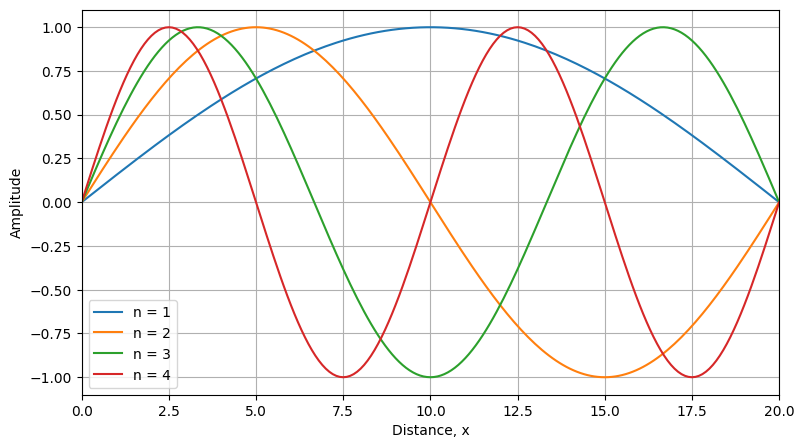

In [ ]:
# Plot the first four normal modes
plt.figure(figsize=(9, 5))

for mode_number in range(1, 5):
    U_n = np.sin(mode_number * np.pi * x / L)
    plt.plot(x, U_n, label=f"n = {mode_number}")

plt.xlabel("Distance, x")
plt.ylabel("Amplitude")
plt.xlim(0, L)
plt.legend()
plt.grid()
plt.show()

### Normal Mode Summation

The displacement of the string is obtained by summing the contribution of the first 40 normal modes:

$$
u(x,t)
=
\sum_{n=1}^{40}
A_n
\sin\left(\frac{n\pi x}{L}\right)
\cos(\omega_n t).
$$

This allows the displacement along the entire string to be calculated at any selected time.

In [ ]:
def normal_mode_sum(x, t):

    u = np.zeros_like(x)

    for i in range(N):

        mode_shape = np.sin(n[i] * np.pi * x / L)
        time_term = np.cos(omega_n[i] * t)

        u += A_n[i] * mode_shape * time_term

    return u

### Displacement at $t=1.5$ s

The displacement is first calculated at $t=1.5$ s. At this time, the waves have traveled

$$
ct=(3)(1.5)=4.5
$$

units from the source. Since the source is located at $x_s=8$, the two pulses are expected near $x=3.5$ and $x=12.5$.

In [ ]:
t = 1.5
u_1_5 = normal_mode_sum(x, t)

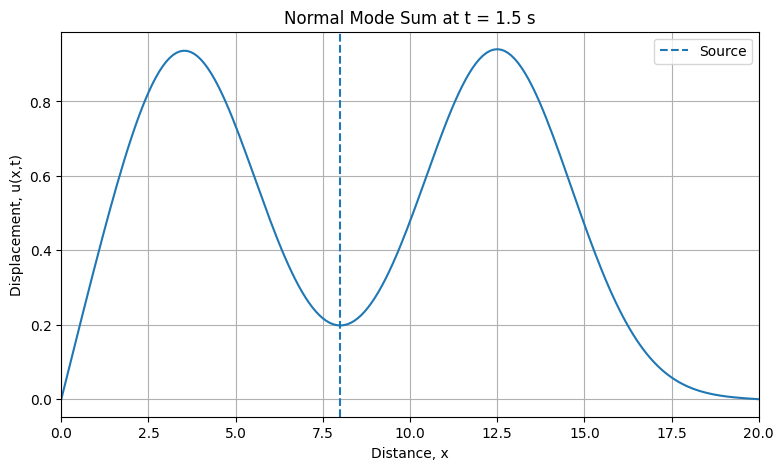

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(x, u_1_5)
plt.axvline(x=x_s, linestyle="--", label="Source")

plt.xlabel("Distance, x")
plt.ylabel("Displacement, u(x,t)")
plt.title("Normal Mode Sum at t = 1.5 s")
plt.xlim(0, L)
plt.grid()
plt.legend()

plt.show()

### Displacement at $t=5$ and $10$ s

The same normal mode summation is used to calculate the displacement at $t=5$ and $10$ s. Unlike the result at $t=1.5$ s, the waves have reached the fixed boundaries at these later times, so the effect of reflection can be observed.

In [ ]:
u_5 = normal_mode_sum(x, 5)
u_10 = normal_mode_sum(x, 10)

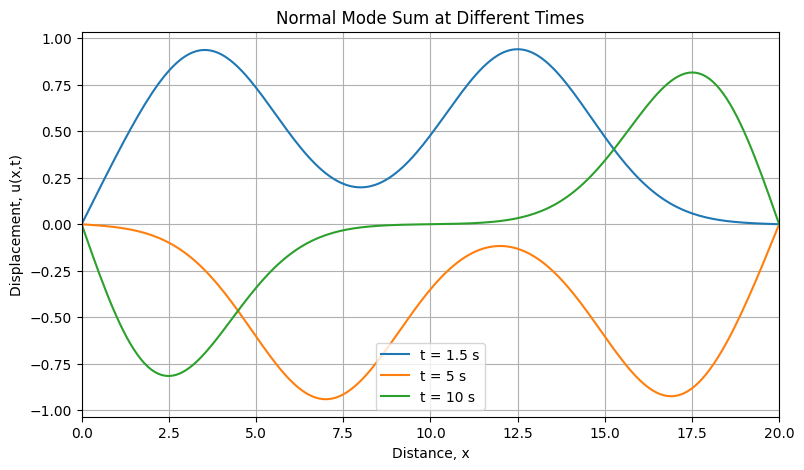

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(x, u_1_5, label="t = 1.5 s")
plt.plot(x, u_5, label="t = 5 s")
plt.plot(x, u_10, label="t = 10 s")

plt.xlabel("Distance, x")
plt.ylabel("Displacement, u(x,t)")
plt.title("Normal Mode Sum at Different Times")
plt.xlim(0, L)
plt.grid()
plt.legend()

plt.show()

In [ ]:
# Checking the boundaries just in case
for t in [1.5, 5, 10]:
    u = normal_mode_sum(x, t)

    print(
        f"t = {t:4.1f} s: "
        f"u(0,t) = {u[0]:.2e}, "
        f"u(L,t) = {u[-1]:.2e}"
    )

t =  1.5 s: u(0,t) = 0.00e+00, u(L,t) = 4.87e-18
t =  5.0 s: u(0,t) = 0.00e+00, u(L,t) = -3.57e-16
t = 10.0 s: u(0,t) = 0.00e+00, u(L,t) = 4.18e-16


### Comparison with Slide 27

The example on Slide 27 uses $L=20$, $c=1$, $x_s=8$, and $\tau=0.2$, while Problem 1 uses $L=20$, $c=3$, $x_s=8$, and $\tau=1$. The two results at $t=1.5$ s are plotted together below for comparison.

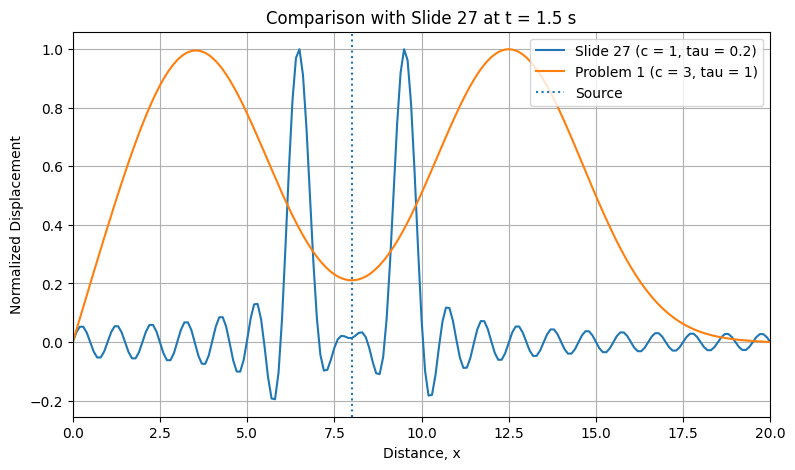

In [ ]:
# Comparison between Problem 1 and Slide 27 at t = 1.5 s

t = 1.5

# Problem 1
u_problem = normal_mode_sum(x, t)

# Slide 27 parameters
c_slide = 1.0
tau_slide = 0.2

omega_slide = n * np.pi * c_slide / L

F_slide = np.exp(
    -(omega_slide * tau_slide)**2 / 4
)

A_slide = (
    np.sin(n * np.pi * x_s / L)
    * F_slide
)

u_slide = np.zeros_like(x)

for i in range(N):
    u_slide += (
        A_slide[i]
        * np.sin(n[i] * np.pi * x / L)
        * np.cos(omega_slide[i] * t)
    )

# Normalize for comparison
u_problem_norm = u_problem / np.max(np.abs(u_problem))
u_slide_norm = u_slide / np.max(np.abs(u_slide))

# Plot
plt.figure(figsize=(9, 5))

plt.plot(
    x, u_slide_norm,
    label="Slide 27 (c = 1, tau = 0.2)"
)

plt.plot(
    x, u_problem_norm,
    label="Problem 1 (c = 3, tau = 1)"
)

plt.axvline(
    x=x_s,
    linestyle=":",
    label="Source"
)

plt.xlabel("Distance, x")
plt.ylabel("Normalized Displacement")
plt.title("Comparison with Slide 27 at t = 1.5 s")
plt.xlim(0, L)
plt.grid()
plt.legend()

plt.show()

### Wave Propagation for the Homework and Lecture Parameters

The wave propagation is shown below using the parameters from the homework and the example from Lecture 6. The same time slices are used in both cases to compare the effect of the different values of $c$ and $\tau$.

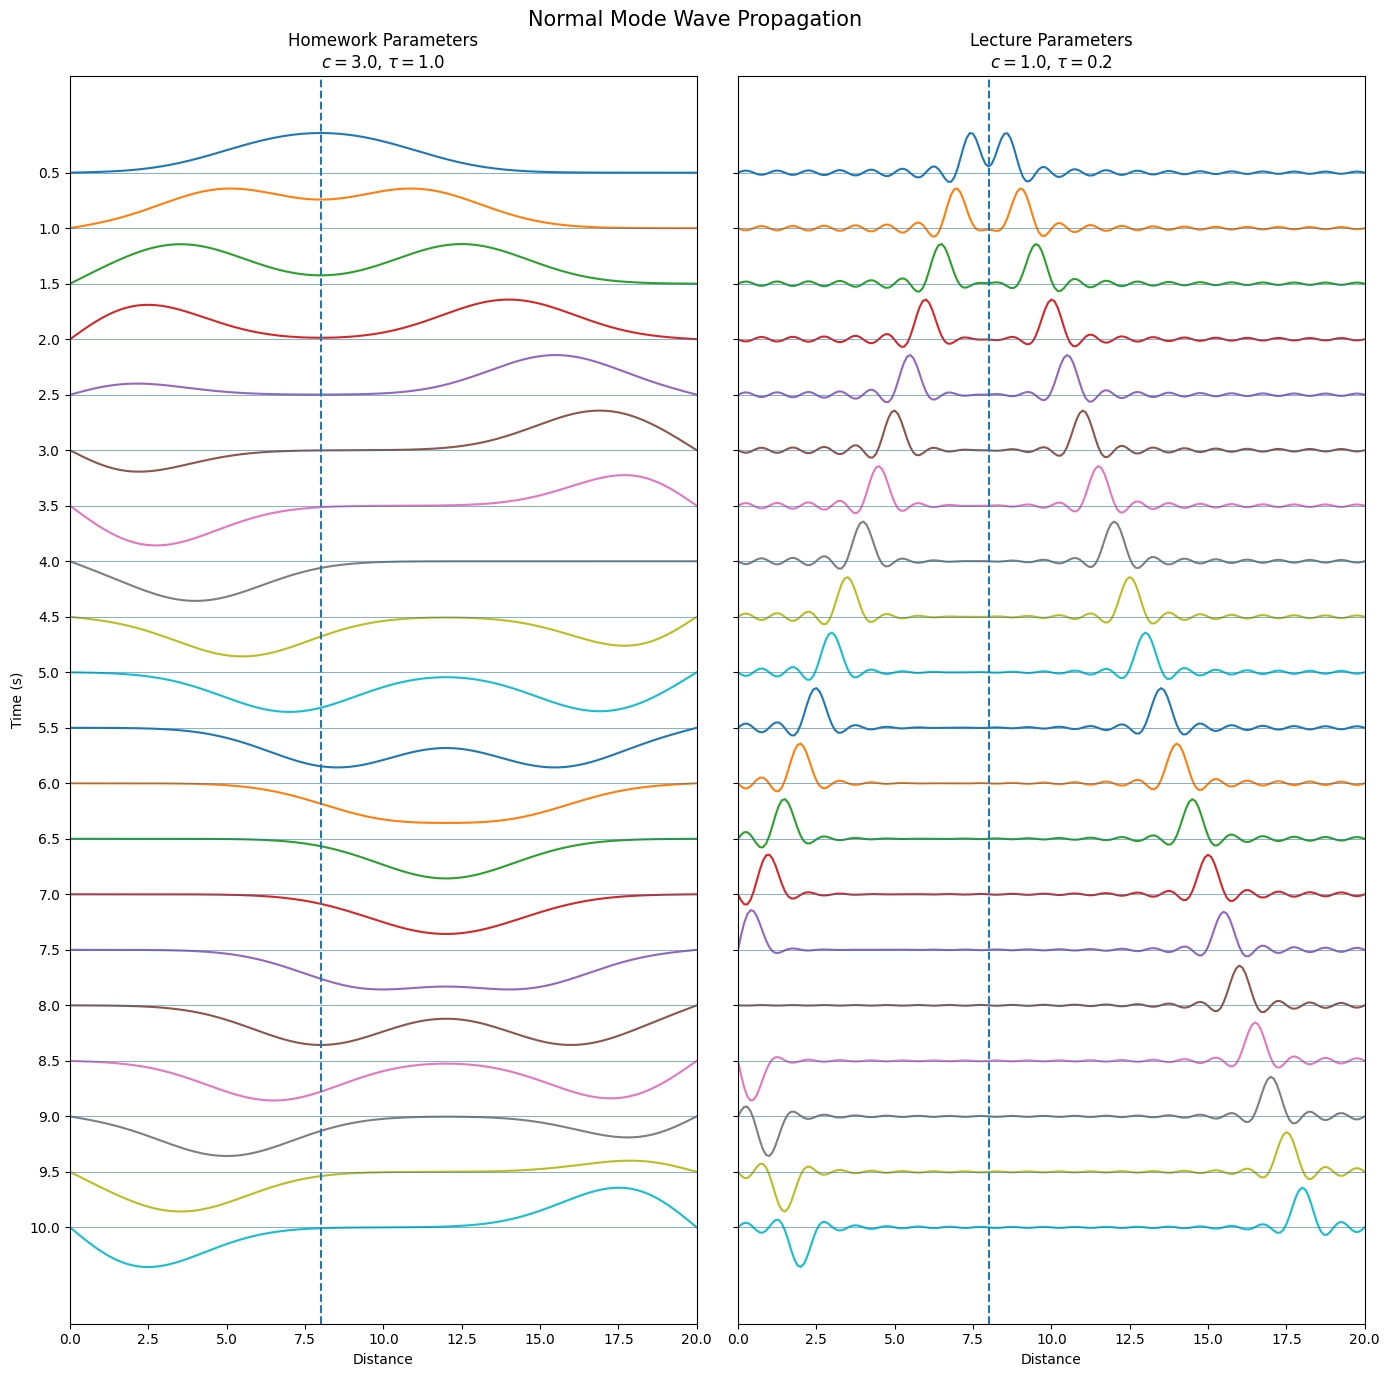

In [ ]:
# Time slices from 0.5 to 10 s
times = np.arange(0.5, 10.1, 0.5)

# Homework parameters
c_hw = 3.0
tau_hw = 1.0

# Lecture parameters
c_lec = 1.0
tau_lec = 0.2


def mode_sum_parameters(x, t, c_value, tau_value):

    omega = n * np.pi * c_value / L

    F = np.exp(
        -(omega * tau_value)**2 / 4
    )

    A = (
        np.sin(n * np.pi * x_s / L)
        * F
    )

    u = np.zeros_like(x)

    for i in range(N):
        u += (
            A[i]
            * np.sin(n[i] * np.pi * x / L)
            * np.cos(omega[i] * t)
        )

    return u


# Two-column figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

cases = [
    ("Homework Parameters", c_hw, tau_hw),
    ("Lecture Parameters", c_lec, tau_lec)
]

spacing = 1.4

for ax, (title, c_value, tau_value) in zip(axes, cases):

    for j, t in enumerate(times):

        u = mode_sum_parameters(
            x, t, c_value, tau_value
        )

        # Normalize each time slice for visualization
        u_plot = u / np.max(np.abs(u))

        # Negative baseline makes time increase downward
        baseline = -j * spacing

        ax.plot(
            x,
            baseline + u_plot,
            linewidth=1.5
        )

        ax.axhline(
            baseline,
            linewidth=0.4
        )

    # Source location
    ax.axvline(
        x_s,
        linestyle="--",
        linewidth=1.5
    )

    ax.set_title(
        f"{title}\n"
        f"$c={c_value}$, $\\tau={tau_value}$"
    )

    ax.set_xlabel("Distance")
    ax.set_xlim(0, L)

# Time labels
baselines = [-j * spacing for j in range(len(times))]

axes[0].set_yticks(baselines)
axes[0].set_yticklabels(
    [f"{t:.1f}" for t in times]
)

axes[0].set_ylabel("Time (s)")

fig.suptitle(
    "Normal Mode Wave Propagation",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Observations

The two cases show noticeably different wave behavior because different values of $c$ and $\tau$ are used. For the homework parameters ($c=3$, $\tau=1$), the pulses are broader and travel faster along the string. The first reflections from the boundaries can already be seen within the first few seconds, and the pulse direction and polarity continue to change as time increases.

For the lecture parameters ($c=1$, $\tau=0.2$), the pulses travel more slowly and remain much narrower. Small oscillations are also visible around the main pulses because the smaller value of $\tau$ allows more of the higher modes to contribute to the sum. Since the wave velocity is lower, the pulses reach the boundaries later than in the homework case.

Overall, increasing $c$ changes how quickly the pulses move through the string, while changing $\tau$ mainly affects their width and the amount of small oscillation around them.

### Observations at 5 and 10 s

At $t=1.5$ s, the two pulses have moved away from the source in opposite directions. With $c=3$, they are centered near $x=3.5$ and $x=12.5$.

By $t=5$ s, both pulses have reached the fixed ends of the string and reflected. The reflected pulses have reversed polarity and are traveling back into the string.

At $t=10$ s, the pulses have continued to propagate and reflect from the fixed boundaries. Their locations and polarities have changed again compared with the earlier time slices. The displacement remains zero at both ends throughout the motion because the string is fixed at $x=0$ and $x=20$.

# Problem 2

This problem uses Snell's law to find the P-wave velocity inside the corner-shaped medium. The ray crosses two interfaces: first a horizontal interface and then a vertical interface.

The angles used in Snell's law are measured from the **normal to the interface**, so the given angles must first be converted.

### Given Parameters

The P-wave velocity outside the corner-shaped medium is

$$
\alpha_1 = 6 \text{ km/s}.
$$

At the first horizontal interface, the incident ray is $60^\circ$ from the horizontal. Since the normal to this interface is vertical, the angle from the normal is

$$
\theta_1 = 90^\circ - 60^\circ = 30^\circ.
$$

At the second vertical interface, the final ray is $75^\circ$ from the vertical. The normal to this interface is horizontal, so the final angle from the normal is

$$
\theta_3 = 90^\circ - 75^\circ = 15^\circ.
$$

In [ ]:
# Given P-wave velocity
alpha_1 = 6.0  # km/s

# Given angles
incident_angle = 60.0  # degrees from horizontal
final_angle = 75.0     # degrees from vertical

# Convert to angles measured from the interface normals
theta_1 = 90.0 - incident_angle
theta_3 = 90.0 - final_angle

print(f"Angle at the first interface = {theta_1:.1f} degrees")
print(f"Angle at the second interface = {theta_3:.1f} degrees")

Angle at the first interface = 30.0 degrees
Angle at the second interface = 15.0 degrees


### Applying Snell's Law

For the first horizontal interface, Snell's law gives

$$
\frac{\sin\theta_1}{\alpha_1}
=
\frac{\sin\theta_2}{\alpha_2},
$$

where $\theta_2$ is the angle of the ray inside the corner-shaped medium measured from the vertical normal.

Using $\theta_1=30^\circ$,

$$
\frac{\sin30^\circ}{6}
=
\frac{\sin\theta_2}{\alpha_2}.
$$

At the second interface, the normal is horizontal. Let the angle of the ray inside the medium measured from this normal be $\phi$. Since the horizontal and vertical normals are perpendicular,

$$
\theta_2+\phi=90^\circ.
$$

Snell's law at the second interface is

$$
\frac{\sin\phi}{\alpha_2}
=
\frac{\sin15^\circ}{6}.
$$

Therefore, the two equations are

$$
\frac{\sin\theta_2}{\alpha_2}
=
\frac{\sin30^\circ}{6}
$$

and

$$
\frac{\sin\phi}{\alpha_2}
=
\frac{\sin15^\circ}{6},
$$

with

$$
\theta_2+\phi=90^\circ.
$$
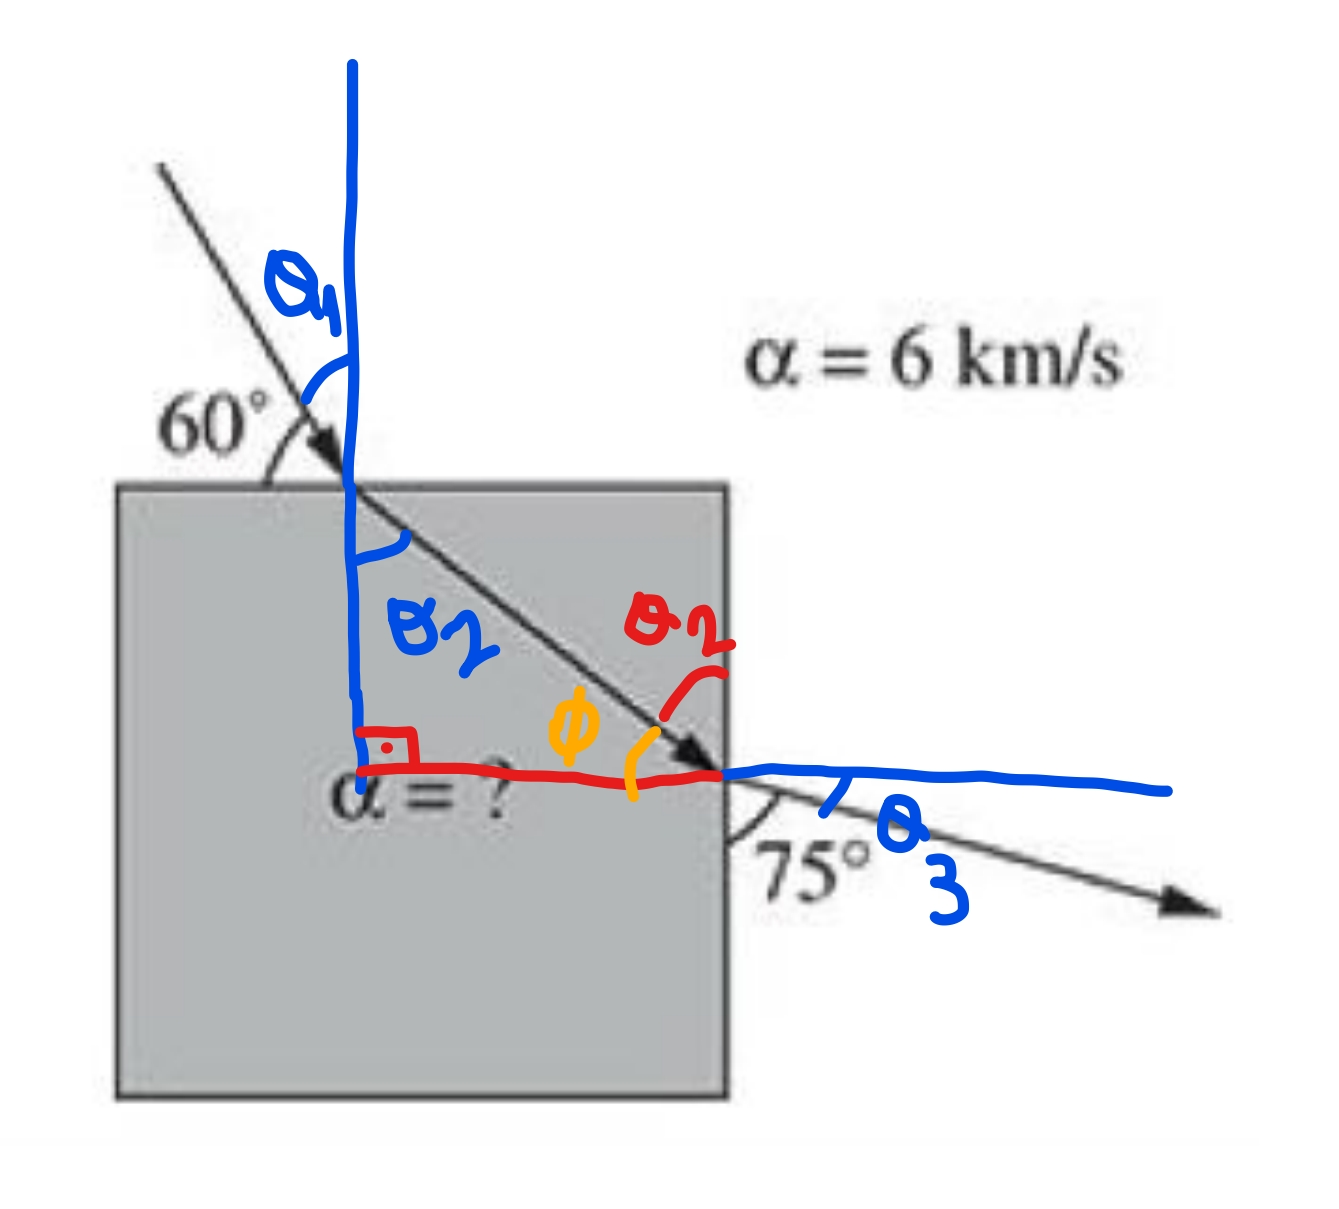

### Solving for the P-Wave Velocity

From Snell's law at the first interface,

$$
\frac{\sin\theta_1}{\alpha_1}
=
\frac{\sin\theta_2}{\alpha_2}.
$$

Using $\theta_1=30^\circ$ and $\alpha_1=6$ km/s,

$$
\frac{\sin30^\circ}{6}
=
\frac{\sin\theta_2}{\alpha_2}.
$$

At the second interface,

$$
\frac{\sin\phi}{\alpha_2}
=
\frac{\sin\theta_3}{\alpha_1}.
$$

Using $\theta_3=15^\circ$ and $\alpha_1=6$ km/s,

$$
\frac{\sin\phi}{\alpha_2}
=
\frac{\sin15^\circ}{6}.
$$

Since the two interfaces are perpendicular,

$$
\theta_2+\phi=90^\circ.
$$

From the first interface,

$$
\alpha_2
=
6\frac{\sin\theta_2}{\sin30^\circ}.
$$

From the second interface,

$$
\alpha_2
=
6\frac{\sin\phi}{\sin15^\circ}.
$$

Since both expressions are equal to $\alpha_2$,

$$
6\frac{\sin\theta_2}{\sin30^\circ}
=
6\frac{\sin\phi}{\sin15^\circ}.
$$

Canceling 6,

$$
\frac{\sin\theta_2}{\sin30^\circ}
=
\frac{\sin\phi}{\sin15^\circ}.
$$

Using

$$
\phi=90^\circ-\theta_2,
$$

gives

$$
\frac{\sin\theta_2}{\sin30^\circ}
=
\frac{\sin(90^\circ-\theta_2)}{\sin15^\circ}.
$$

Solving this equation gives

$$
\theta_2=62.63^\circ.
$$

Therefore,

$$
\phi=90^\circ-62.63^\circ=27.37^\circ.
$$

The P-wave velocity inside the corner-shaped medium can now be calculated using the first interface:

$$
\alpha_2
=
6\frac{\sin62.63^\circ}{\sin30^\circ}.
$$

Therefore,

$$
\boxed{\alpha_2=10.66\ \text{km/s}}.
$$

In [ ]:
from scipy.optimize import brentq

# Given values
alpha_1 = 6.0       # km/s
theta_1 = 30.0      # degrees
theta_3 = 15.0      # degrees

# Equation obtained from Snell's law at both interfaces
def equation(theta_2):
    phi = 90.0 - theta_2

    return (
        np.sin(np.radians(theta_2)) / np.sin(np.radians(theta_1))
        -
        np.sin(np.radians(phi)) / np.sin(np.radians(theta_3))
    )

# Solve for theta_2
theta_2 = brentq(equation, 0.01, 89.99)

# Angle at the second interface
phi = 90.0 - theta_2

# P-wave velocity inside the corner-shaped medium
alpha_2 = (
    alpha_1
    * np.sin(np.radians(theta_2))
    / np.sin(np.radians(theta_1))
)

print(f"theta_2 = {theta_2:.2f} degrees")
print(f"phi = {phi:.2f} degrees")
print(f"P-wave velocity = {alpha_2:.2f} km/s")

theta_2 = 62.63 degrees
phi = 27.37 degrees
P-wave velocity = 10.66 km/s


# Problem 3a

The goal of this problem is to calculate theoretical seismic travel times using the **ak135 velocity model** and reproduce the general travel-time pattern shown in Figure 4.19.

The source depth is fixed at

$$
h = 40\ \text{km},
$$

and epicentral distance is evaluated from $0^\circ$ to $180^\circ$ using a spacing of

$$
\Delta x = 0.1^\circ.
$$

For each epicentral distance, ObsPy's `TauPyModel` is used to calculate the possible seismic phase arrivals. Each arrival is plotted as an individual point rather than connecting the arrivals with lines.

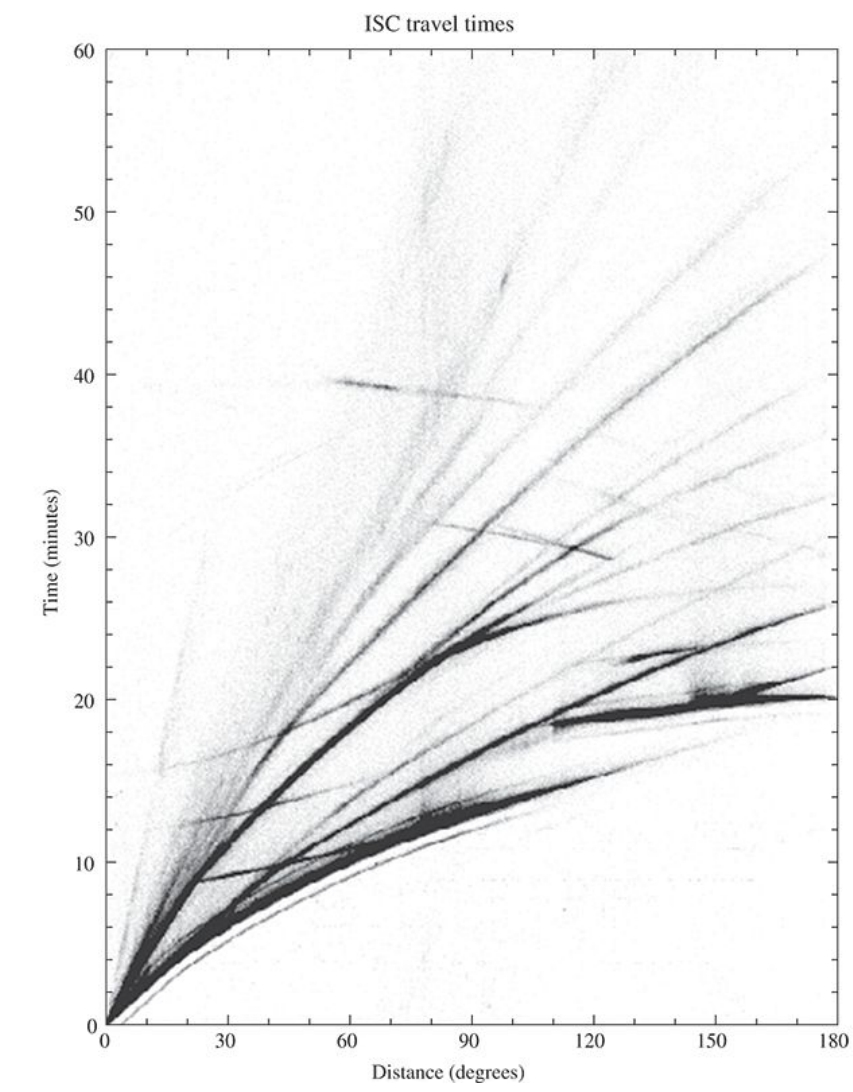

In [2]:
!pip install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 81.0 MB/s eta 0:00:00


In [1]:
from obspy.taup import TauPyModel

# Load the ak135 Earth velocity model
model = TauPyModel(model="ak135")

### Epicentral Distance

The travel times are calculated at $0.1^\circ$ intervals over the full epicentral distance range:

$$
0^\circ \leq \Delta \leq 180^\circ.
$$

In [4]:
# Source depth and distance range
source_depth = 40.0  # km
distances = np.arange(0.0, 180.0 + 0.1, 0.1)

print(f"Number of distance points = {len(distances)}")

Number of distance points = 1801


### Example Arrival Calculation

Before calculating the full travel-time diagram, the arrivals at an epicentral distance of $5^\circ$ are examined. The model may return multiple arrivals because seismic energy can travel between the source and receiver along different ray paths and as different seismic phases.

In [5]:
# Example at 5 degrees
arrivals = model.get_travel_times(
    source_depth_in_km=source_depth,
    distance_in_degree=5
)

print(f"Number of arrivals = {len(arrivals)}")

for arrival in arrivals:
    print(
        f"{arrival.name:8s} "
        f"{arrival.time:8.2f} s"
    )

Number of arrivals = 22
P           72.49 s
sP          85.85 s
sP          97.22 s
sP          97.31 s
sP         104.07 s
sP         104.22 s
S          129.01 s
PcP        506.50 s
ScP        714.49 s
PcS        718.90 s
ScS        927.19 s
PKiKP      988.68 s
pPKiKP    1001.44 s
sPKiKP    1005.85 s
SKiKP     1196.33 s
PKIKKIKP  1906.64 s
SKIKKIKP  2114.29 s
PKIKKIKS  2118.70 s
SKIKKIKS  2326.35 s
PKIKPPKIKP  2418.23 s
PKPPKP    2629.69 s
SKIKSSKIKS  3262.09 s


### Travel-Time Calculation

The same calculation is repeated from $0^\circ$ to $180^\circ$ at $0.1^\circ$ intervals. At each distance, all theoretical arrivals returned by the ak135 model are stored.

Since more than one seismic phase can arrive at the same epicentral distance, each distance may have multiple corresponding travel times.

In [6]:
# Lists to store all theoretical arrivals
arrival_distances = []
arrival_times = []

# Calculate arrivals at each epicentral distance
for distance in distances:

    arrivals = model.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance
    )

    # Store every arrival at this distance
    for arrival in arrivals:

        arrival_distances.append(distance)

        # Convert seconds to minutes
        arrival_times.append(arrival.time / 60.0)

print(f"Total number of theoretical arrivals = {len(arrival_times)}")

Total number of theoretical arrivals = 55615


### Theoretical Travel-Time Curves

A total of 55,615 theoretical arrivals were calculated using the ak135 velocity model. The arrival times are plotted below as individual points as a function of epicentral distance.

Travel time is converted from seconds to minutes to match Figure 4.19.

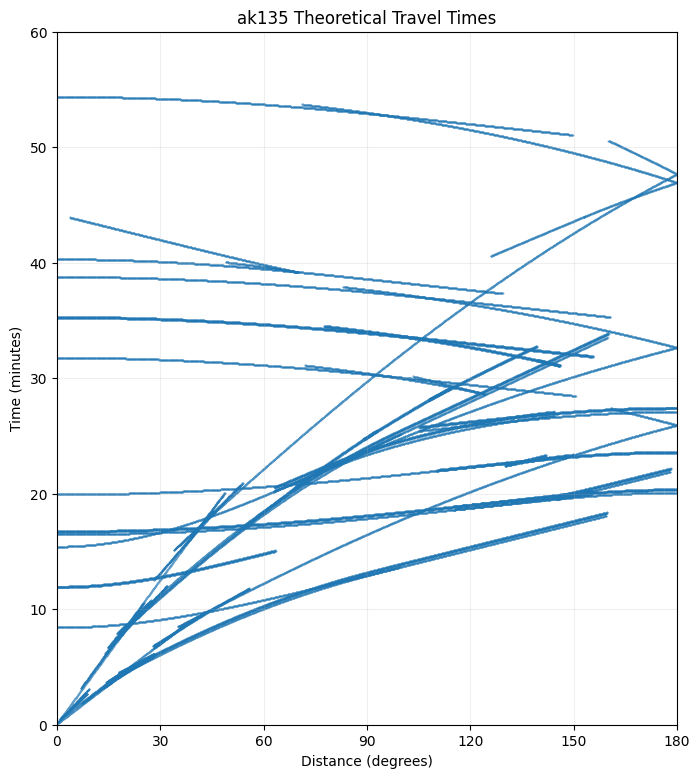

In [8]:
# Plot all theoretical arrivals

plt.figure(figsize=(8, 9))

plt.scatter(
    arrival_distances,
    arrival_times,
    s=0.5,
    alpha=0.6,
    marker="."
)

plt.xlabel("Distance (degrees)")
plt.ylabel("Time (minutes)")
plt.title("ak135 Theoretical Travel Times")

plt.xlim(0, 180)
plt.ylim(0, 60)

plt.xticks(np.arange(0, 181, 30))
plt.yticks(np.arange(0, 61, 10))

plt.grid(alpha=0.2)

plt.show()

### Observation

The ak135 model produces several distinct travel-time branches over the full distance range. Compared with Figure 4.19, the theoretical arrivals form much sharper patterns, while the observed ISC arrivals show more scatter. The overall travel-time patterns are still similar, with multiple arrivals occurring at the same epicentral distance.

# Problem 3b

For this problem, a broadband vertical-component (HHZ) seismic record is used for an earthquake with a magnitude of approximately 7.5. The station is selected to be approximately $90^\circ$ from the earthquake.

The observed waveform is compared with theoretical seismic phase arrival times calculated using the ak135 velocity model. The theoretical arrivals are then labeled on the waveform to identify the seismic phases observed during the first hour after the earthquake.

In [9]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.geodetics import locations2degrees

In [22]:
client = Client("IRIS")

/usr/local/lib/python3.13/dist-packages/obspy/clients/fdsn/client.py:257: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


### Event Selection

The 2024 Noto Peninsula earthquake is selected for the waveform analysis. The event parameters are:

- Origin time: January 1, 2024 at 07:10:09 UTC
- Magnitude: $M_w$ 7.5
- Latitude: $37.487^\circ$ N
- Longitude: $137.271^\circ$ E
- Depth: 10 km

A broadband HHZ station approximately $90^\circ$ from the earthquake will be selected for the analysis.

In [23]:
# 2024 Noto Peninsula earthquake
origin_time = UTCDateTime("2024-01-01T07:10:09")

event_lat = 37.487
event_lon = 137.271
event_depth = 10.0  # km
event_magnitude = 7.5

In [24]:
# Search for HHZ stations approximately 90 degrees from the earthquake

inventory = client.get_stations(
    starttime=origin_time,
    endtime=origin_time + 3600,
    latitude=event_lat,
    longitude=event_lon,
    minradius=85,
    maxradius=95,
    channel="HHZ",
    level="channel"
)

print(inventory)

Inventory created at 2026-09-28T17:55:32.793800Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (53):
			16, 4T, 6O, 7D, 7O, 8H, AE, AG, AO, AU, C0, C8, CA, CN, EI, EP, G, 
			GB, GM, GS, HZ, IU, KY, LD, LM, MN, MR, MU, MX, N4, NE, NM, NW, NX
			NZ, O2, OH, OK, PE, PI, PN, PO, RB, RE, SC, SS, TT, TX, UK, WM, 
			WU, YU, YX
		Stations (697):
			16.MG09 (MG09)
			16.MG10 (MG10)
			16.MG11 (MG11)
			16.MG12 (MG12)
			16.MG13 (MG13)
			16.MG14 (MG14)
			4T.NM01 (WSW of Eunice,  NM)
			4T.NM02 (Loving,  NM)
			4T.NM03 (WNW of Eunice, NM)
			6O.OHIO (OHIO)
			6O.SHOE (SHOE)
			7D.COMM (COMM)
			7D.ELDE (ELDE)
			7D.GRVF (GRVF)
			7D.IVOR (IVOR)
			7D.LUXM (LUXM)
			7D.MIKE (MIKE)
			7D.RIMM (RIMM)
			7D.RNLD (RNLD)
			7D.ROBB (ROBB)
			7D.STEPH (STEPH)
			7D.TEAD (TEAD)
			7D.THIC (THIC)
			7O.BBVT (Burr and Burton Academy)
		

In [25]:
station_list = []

for network in inventory:
    for station in network:

        distance_deg = locations2degrees(
            event_lat,
            event_lon,
            station.latitude,
            station.longitude
        )

        station_list.append(
            (
                network.code,
                station.code,
                station.latitude,
                station.longitude,
                distance_deg
            )
        )

# Sort by closeness to 90 degrees
station_list.sort(
    key=lambda x: abs(x[4] - 90)
)

# Show the 10 closest stations
for station in station_list[:10]:
    print(
        f"{station[0]}.{station[1]:6s} "
        f"Lat = {station[2]:8.3f}, "
        f"Lon = {station[3]:9.3f}, "
        f"Distance = {station[4]:6.2f}°"
    )

TX.PB38   Lat =   31.730, Lon =  -104.427, Distance =  90.00°
TX.PB28   Lat =   31.669, Lon =  -104.501, Distance =  90.00°
NX.STN19  Lat =   36.683, Lon =   -97.903, Distance =  89.99°
GM.NMP12  Lat =   32.128, Lon =  -103.953, Distance =  89.99°
GM.NMP01  Lat =   32.205, Lon =  -103.860, Distance =  89.99°
NX.WTX36  Lat =   31.957, Lon =  -104.122, Distance =  90.01°
TX.PB36   Lat =   31.680, Lon =  -104.426, Distance =  90.03°
RB.UAGRB  Lat =   25.562, Lon =  -111.257, Distance =  89.97°
GM.NMP35  Lat =   32.352, Lon =  -103.725, Distance =  89.96°
O2.KS13   Lat =   37.013, Lon =   -97.478, Distance =  89.96°


In [27]:
working_stations = []

for net, sta, lat, lon, dist in station_list:

    try:
        st_test = client.get_waveforms(
            network=net,
            station=sta,
            location="*",
            channel="HHZ",
            starttime=origin_time,
            endtime=origin_time + 3600
        )

        # Keep only stations with waveform data
        if len(st_test) > 0:
            working_stations.append(
                (net, sta, lat, lon, dist, len(st_test))
            )

            print(
                f"{net}.{sta:6s} "
                f"Distance = {dist:6.2f}°   "
                f"Traces = {len(st_test)}"
            )

        # Stop after finding 5 working stations
        if len(working_stations) == 5:
            break

    except Exception:
        continue

TX.PB38   Distance =  90.00°   Traces = 1
TX.PB28   Distance =  90.00°   Traces = 1
GM.NMP12  Distance =  89.99°   Traces = 1
GM.NMP01  Distance =  89.99°   Traces = 1
NX.WTX36  Distance =  90.01°   Traces = 1


### Station Selection

Station GM.NMP12 was selected for the analysis. The station is approximately $90^\circ$ from the earthquake and has an available HHZ recording for the first hour after the event.

In [29]:
network = "GM"
station = "NMP12"

st = client.get_waveforms(
    network=network,
    station=station,
    location="*",
    channel="HHZ",
    starttime=origin_time,
    endtime=origin_time + 3600
)

print(st)

1 Trace(s) in Stream:
GM.NMP12.01.HHZ | 2024-01-01T07:10:09.000000Z - 2024-01-01T08:10:09.000000Z | 200.0 Hz, 720001 samples


In [30]:
st.detrend("demean")
st.detrend("linear")

tr = st[0]

### Waveform Processing

The HHZ waveform contains one continuous trace covering the first hour after the earthquake, so merging is not necessary. The mean and linear trend are removed before examining the seismic arrivals.

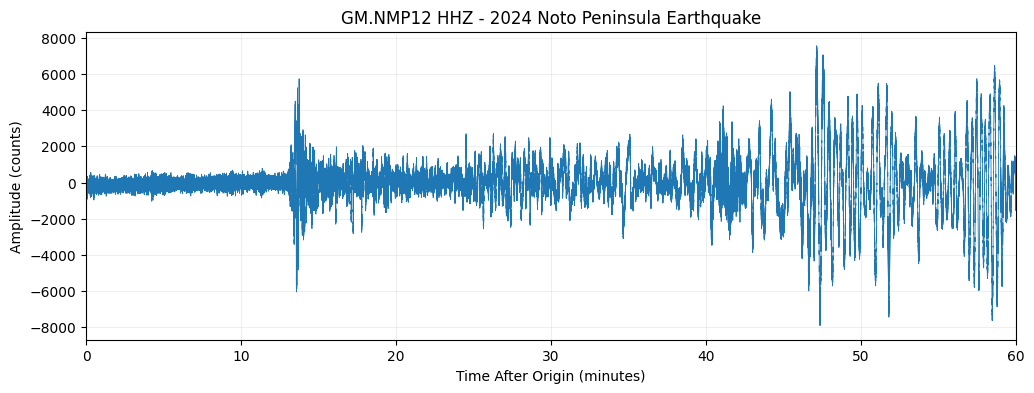

In [31]:
time_min = tr.times() / 60.0

plt.figure(figsize=(12, 4))

plt.plot(time_min, tr.data, linewidth=0.6)

plt.xlabel("Time After Origin (minutes)")
plt.ylabel("Amplitude (counts)")
plt.title("GM.NMP12 HHZ - 2024 Noto Peninsula Earthquake")

plt.xlim(0, 60)
plt.grid(alpha=0.2)

plt.show()

### Theoretical Phase Arrivals

Theoretical phase arrival times are calculated using the ak135 velocity model for the source depth and epicentral distance of the selected earthquake-station pair. Only arrivals within the first hour after the earthquake are considered.

In [32]:
# GM.NMP12 coordinates
station_lat = 32.128
station_lon = -103.953

# Calculate epicentral distance
distance_deg = locations2degrees(
    event_lat,
    event_lon,
    station_lat,
    station_lon
)

# Calculate theoretical arrivals
arrivals = model.get_travel_times(
    source_depth_in_km=event_depth,
    distance_in_degree=distance_deg
)

print(f"Epicentral distance = {distance_deg:.2f} degrees\n")

for arrival in arrivals:
    if arrival.time <= 3600:
        print(
            f"{arrival.name:10s} "
            f"{arrival.time:8.2f} s   "
            f"{arrival.time/60:6.2f} min"
        )

Epicentral distance = 89.99 degrees

P            779.67 s    12.99 min
PcP          780.90 s    13.02 min
pP           783.02 s    13.05 min
sP           784.20 s    13.07 min
PP           992.54 s    16.54 min
PKiKP       1075.86 s    17.93 min
pPKiKP      1079.29 s    17.99 min
sPKiKP      1080.46 s    18.01 min
SKiKP       1290.35 s    21.51 min
SKS         1410.58 s    23.51 min
pSKS        1415.07 s    23.58 min
sSKS        1416.27 s    23.60 min
SKKS        1423.81 s    23.73 min
S           1432.56 s    23.88 min
ScS         1436.70 s    23.94 min
pS          1436.84 s    23.95 min
sS          1438.10 s    23.97 min
SP          1497.83 s    24.96 min
SP          1498.13 s    24.97 min
SP          1498.32 s    24.97 min
PS          1499.16 s    24.99 min
PS          1499.44 s    24.99 min
PS          1499.64 s    24.99 min
SS          1790.46 s    29.84 min
PKIKKIKP    1826.24 s    30.44 min
PKKP        1830.56 s    30.51 min
SKIKKIKP    2040.77 s    34.01 min
PKIKKIKS    2041.9

### Comparison with Theoretical Arrivals

The theoretical arrival times are compared with the observed GM.NMP12 HHZ waveform. Five major phases (P, PP, SKS, S, and SS) are labeled to keep the figure readable.

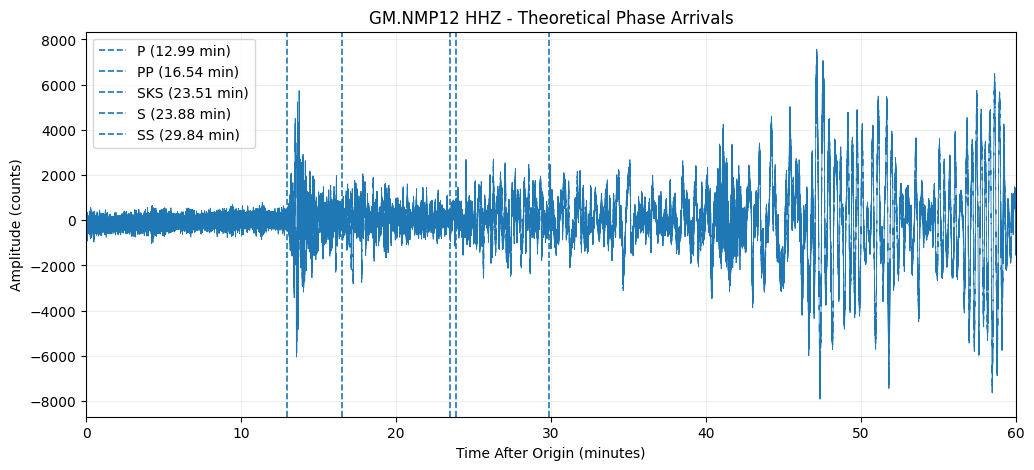

In [33]:
# Select major phases
phases_to_plot = ["P", "PP", "SKS", "S", "SS"]

phase_times = {}

for arrival in arrivals:
    if arrival.name in phases_to_plot and arrival.name not in phase_times:
        phase_times[arrival.name] = arrival.time / 60.0

# Plot observed waveform
plt.figure(figsize=(12, 5))

plt.plot(time_min, tr.data, linewidth=0.6)

# Add theoretical phase arrivals
for phase, arrival_time in phase_times.items():
    plt.axvline(
        arrival_time,
        linestyle="--",
        linewidth=1.2,
        label=f"{phase} ({arrival_time:.2f} min)"
    )

plt.xlabel("Time After Origin (minutes)")
plt.ylabel("Amplitude (counts)")
plt.title("GM.NMP12 HHZ - Theoretical Phase Arrivals")

plt.xlim(0, 60)
plt.grid(alpha=0.2)
plt.legend()

plt.show()

### Filtered Waveform

The P arrival is clearly visible in the unfiltered waveform near its theoretical arrival time. A bandpass filter is also applied to reduce noise and examine whether additional theoretical arrivals can be identified more clearly.

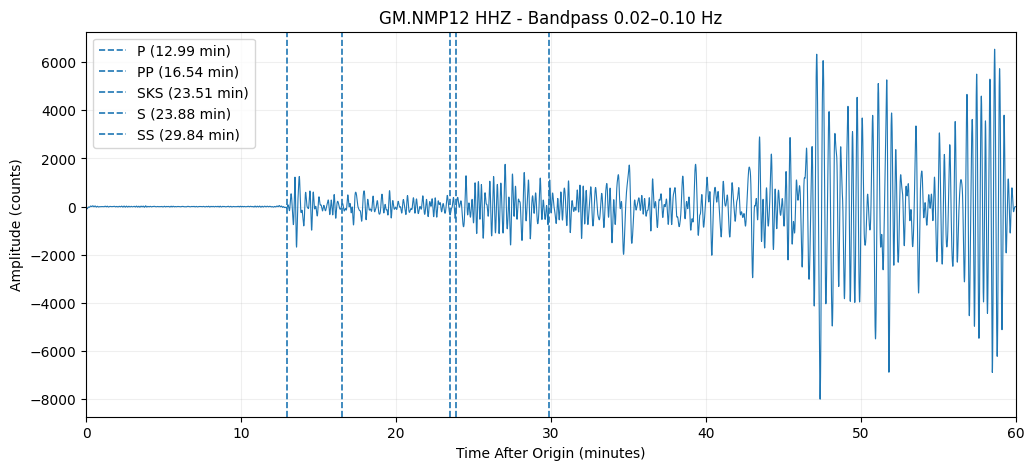

In [34]:
# Copy the waveform before filtering
tr_filt = tr.copy()

# Apply bandpass filter
tr_filt.filter(
    "bandpass",
    freqmin=0.02,
    freqmax=0.10,
    corners=4,
    zerophase=True
)

time_filt_min = tr_filt.times() / 60.0

plt.figure(figsize=(12, 5))

plt.plot(time_filt_min, tr_filt.data, linewidth=0.8)

# Add theoretical phase arrivals
for phase, arrival_time in phase_times.items():
    plt.axvline(
        arrival_time,
        linestyle="--",
        linewidth=1.2,
        label=f"{phase} ({arrival_time:.2f} min)"
    )

plt.xlabel("Time After Origin (minutes)")
plt.ylabel("Amplitude (counts)")
plt.title("GM.NMP12 HHZ - Bandpass 0.02–0.10 Hz")

plt.xlim(0, 60)
plt.grid(alpha=0.2)
plt.legend()

plt.show()

### Observation

The P arrival can be seen clearly at about 12.99 minutes, where the amplitude starts to increase. After applying the bandpass filter, this arrival is easier to see. The later phases, such as PP, SKS, S, and SS, are harder to identify because there is already a lot of seismic energy in the waveform.

# Problem 3c

In this problem, P-wave travel times from the ak135 and PREM velocity models are compared for a source depth of 40 km. Travel times are calculated from $6^\circ$ to $90^\circ$ at $0.1^\circ$ intervals.

The travel-time difference is calculated as

$$
\Delta t = t_{\mathrm{ak135}} - t_{\mathrm{PREM}}.
$$

The P-wave velocity profiles of the two models are also compared to examine how differences in velocity with depth may affect the calculated travel times.

In [35]:
model_ak135 = TauPyModel(model="ak135")
model_prem = TauPyModel(model="prem")

source_depth = 40.0

distances_3c = np.arange(6.0, 90.0 + 0.1, 0.1)

print(f"Number of distance points = {len(distances_3c)}")

Number of distance points = 841


### P-Wave Travel-Time Difference

For each epicentral distance, only the P-wave arrival is calculated from both models. The difference between the ak135 and PREM travel times is then calculated at each distance.

In [36]:
ak135_times = []
prem_times = []
valid_distances = []

for distance in distances_3c:

    arrival_ak135 = model_ak135.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance,
        phase_list=["P"]
    )

    arrival_prem = model_prem.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance,
        phase_list=["P"]
    )

    if len(arrival_ak135) > 0 and len(arrival_prem) > 0:
        valid_distances.append(distance)
        ak135_times.append(arrival_ak135[0].time)
        prem_times.append(arrival_prem[0].time)

valid_distances = np.array(valid_distances)
ak135_times = np.array(ak135_times)
prem_times = np.array(prem_times)

time_difference = ak135_times - prem_times

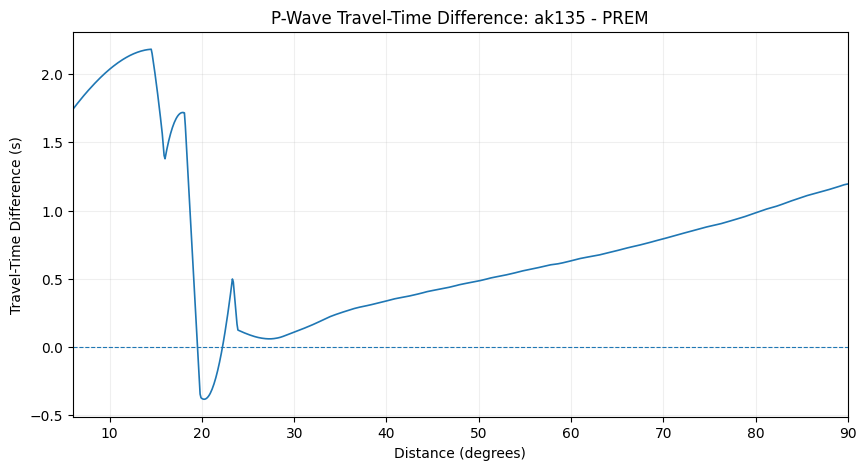

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    valid_distances,
    time_difference,
    linewidth=1.2
)

plt.axhline(0, linestyle="--", linewidth=0.8)

plt.xlabel("Distance (degrees)")
plt.ylabel("Travel-Time Difference (s)")
plt.title("P-Wave Travel-Time Difference: ak135 - PREM")

plt.xlim(6, 90)
plt.grid(alpha=0.2)

plt.show()

### P-Wave Velocity Profiles

The P-wave velocity profiles of the ak135 and PREM models are compared as a function of depth. This allows the differences in the two Earth models to be compared with the P-wave travel-time differences calculated above.

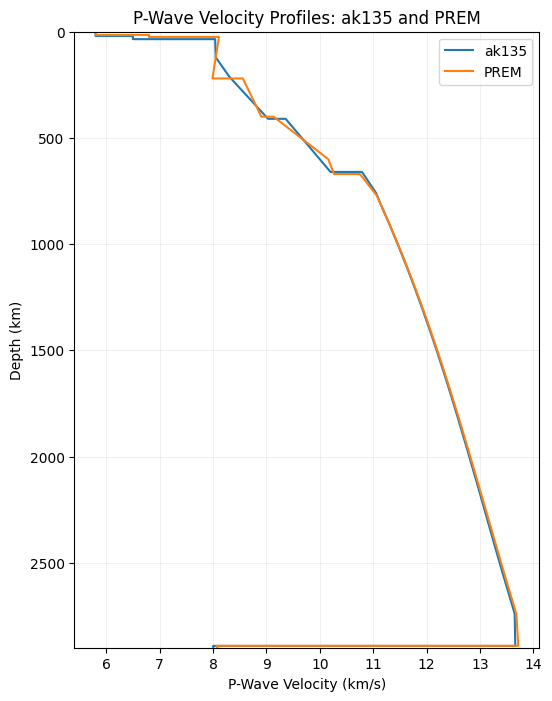

In [41]:
# Get velocity model layers
ak_layers = model_ak135.model.s_mod.v_mod.layers
prem_layers = model_prem.model.s_mod.v_mod.layers

# Create depth and P-wave velocity arrays for ak135
ak_depth = []
ak_vp = []

for layer in ak_layers:
    ak_depth.extend([layer["top_depth"], layer["bot_depth"]])
    ak_vp.extend([layer["top_p_velocity"], layer["bot_p_velocity"]])

# Create depth and P-wave velocity arrays for PREM
prem_depth = []
prem_vp = []

for layer in prem_layers:
    prem_depth.extend([layer["top_depth"], layer["bot_depth"]])
    prem_vp.extend([layer["top_p_velocity"], layer["bot_p_velocity"]])

# Plot
plt.figure(figsize=(6, 8))

plt.plot(ak_vp, ak_depth, label="ak135", linewidth=1.5)
plt.plot(prem_vp, prem_depth, label="PREM", linewidth=1.5)

plt.xlabel("P-Wave Velocity (km/s)")
plt.ylabel("Depth (km)")
plt.title("P-Wave Velocity Profiles: ak135 and PREM")

plt.ylim(2900, 0)
plt.grid(alpha=0.2)
plt.legend()

plt.show()

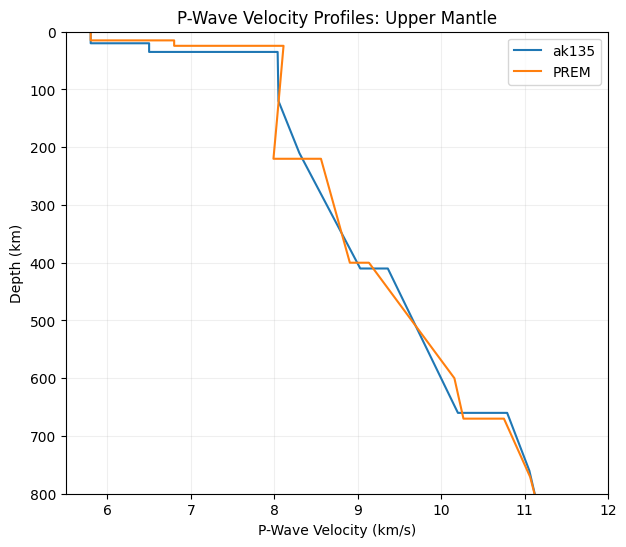

In [42]:
plt.figure(figsize=(7, 6))

plt.plot(ak_vp, ak_depth, label="ak135", linewidth=1.5)
plt.plot(prem_vp, prem_depth, label="PREM", linewidth=1.5)

plt.xlabel("P-Wave Velocity (km/s)")
plt.ylabel("Depth (km)")
plt.title("P-Wave Velocity Profiles: Upper Mantle")

plt.ylim(800, 0)
plt.xlim(5.5, 12)
plt.grid(alpha=0.2)
plt.legend()

plt.show()

### Observation

The P-wave velocity profiles of ak135 and PREM are similar overall, but noticeable differences occur in the upper mantle and transition zone. The velocities and the depths of some velocity changes are slightly different between the two models.

These differences help explain the variation in P-wave travel-time differences with distance. At shorter distances, the P waves sample the shallower parts of the models, where the velocity differences are larger. As distance increases, the rays travel deeper and the travel-time difference changes more gradually as the two velocity profiles become more similar.